# 6 #
(a) Consider (6.12) with p =1. For some choice of y1 and λ > 0,
plot (6.12) as a function of β1. Your plot should confirm that
(6.12) is solved by (6.14).

(6.12)  $\sum{(y_j - \beta_j)^2} + \lambda \sum{\beta_j^2}$

(6.14) $\hat{\beta}_j^R = y_j/(1 + \lambda)$

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

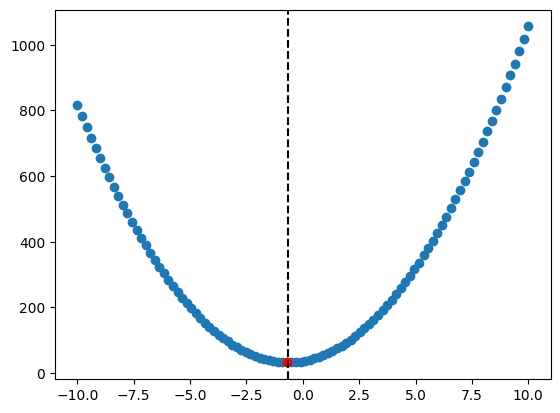

In [77]:
def func_6_12(y, beta, lmbda):
    return (y - beta)**2 + lmbda * beta**2

def func_6_14(y, lmbda):
    beta_ridge = y/(1+lmbda)
    return beta_ridge

lmbda = np.random.randint(low=1, high=10)
y_real = np.random.randint(low=-10, high=10)
valores_beta = np.linspace(-10, 10, 100)

y_predicoes = func_6_12(y_real,valores_beta,lmbda)
beta_min = func_6_14(y_real, lmbda)
plt.scatter(valores_beta, y_predicoes)
plt.scatter(valores_beta[np.argmin(y_predicoes)], np.min(y_predicoes), color='r');
plt.axvline(beta_min, ls='--', c='k')

6(b) Consider (6.13) with p =1. For some choice of y1 and λ > 0,
plot (6.13) as a function of β1. Your plot should confirm that
(6.13) is solved by (6.15).

(6.13) $\sum{(y_j - \beta_j)^2 + \lambda \sum{|\beta_j|}}$

(6.15) $\hat{\beta}_j^L = 
\begin{cases} 
y_j - \lambda/2 & \text{if } y_j > \lambda/2; \\
y_j + \lambda/2 & \text{if } y_j < -\lambda/2;\\
0 & \text{if } |y_j| \leq \lambda/2.
\end{cases}$

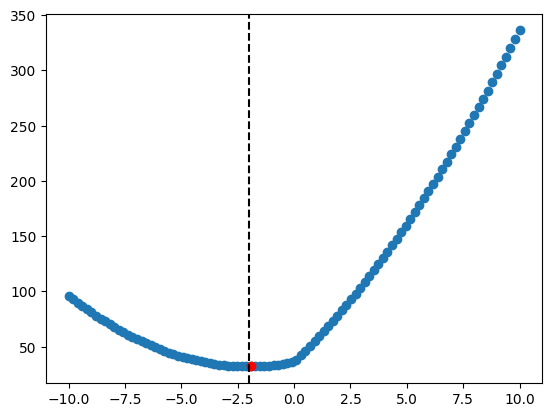

In [78]:
def func_6_13(y, beta, lmbda):
    return (y-beta)**2 + lmbda * np.abs(beta)

def func_6_15(y, lmbda):
    if y > lmbda/2:
        return y - lmbda/2
    elif y < (-lmbda/2):
        return y + lmbda/2
    else:
        return 0

y_predicoes_lasso = func_6_13(y_real, valores_beta, lmbda)
beta_min_lasso = func_6_15(y_real,lmbda)

plt.scatter(valores_beta, y_predicoes_lasso)
plt.scatter(valores_beta[np.argmin(y_predicoes_lasso)], np.min(y_predicoes_lasso), color='r');
plt.axvline(beta_min_lasso, ls='--', c='k')

# 8 #
In this exercise, we will generate simulated data, and will then use
this data to perform forward and backward stepwise selection.

(a) Create a random number generator and use its normal() method
to generate a predictor X of length n = 100, as well as a noise
vector ϵ of length n = 100.

(b) Generate a response vector Y of length n = 100 according to
the model
$Y =\beta_0+\beta_1X+\beta_2X^2+\beta_3X^3+ϵ$,
where β0, β1, β2, and β3 are constants of your choice.

In [79]:
rng = np.random.default_rng(42)
x = rng.normal(size=100)
ruido = rng.normal(size=100)
y = 8 + 4*x + 36*x**2 + 50*x**3 + ruido

$Y =8 +4X+36X^2+50X^3+ϵ$

(c) Use forward stepwise selection in order to select a model contain
ing the predictors $X,X^2,...,X^{10}$. What is the model obtained
according to Cp? Report the coefficients of the model obtained.

fórmula 6.2 página 236 do livro ISLP

$C_p= 1/n (RSS + 2d\hat{\sigma}^2)$

ou

$C_p'=RSS/\hat{\sigma}^2 + 2d - n $

$d =$ número de preditores

$\hat{\sigma}^2 =$ Variância do modelo com todos os preditores



In [80]:
def nCp(variancia, modelo, X, Y):
    n, p = X.shape
    Y_predicoes = modelo.predict(X)
    RSS = np.sum((Y -Y_predicoes)**2)
    return - (RSS + 2 * p * variancia)/n

X = pd.DataFrame()
for i in range(1,11):
    X[f'x_{i}'] = x**i

In [81]:
from statsmodels.api import OLS
from ISLP.models import summarize, ModelSpec


design = ModelSpec(X).fit(X)
modelo_completo = OLS(y, design.transform(X)).fit()
print("R2 modelo completo:", modelo_completo.rsquared)
variancia_modelo_completo = modelo_completo.scale

print("Variância modelo completo:", variancia_modelo_completo)
summarize(modelo_completo)

R2 modelo completo: 0.9998810303564758
Variância modelo completo: 0.9597290861769199


,coef,std err,t,P>|t|
intercept,7.9847,0.235,34.025,0.000
x_1,3.2076,0.728,4.408,0.000
x_2,36.0302,2.335,15.429,0.000
x_3,54.0783,2.970,18.207,0.000
x_4,1.9992,5.774,0.346,0.730
x_5,-5.6819,3.580,-1.587,0.116
x_6,-3.4560,5.223,-0.662,0.510
x_7,2.6060,1.497,1.741,0.085
x_8,1.6232,1.874,0.866,0.389
x_9,-0.3360,0.184,-1.824,0.072


In [82]:
from functools import partial
from ISLP.models import Stepwise, sklearn_selected

neg_Cp = partial(nCp,variancia_modelo_completo)
estrategia_forward = Stepwise.first_peak(model_spec=design,
                                 direction='forward',
                                 max_terms=len(design.terms))
modelo_forward_Cp = sklearn_selected(model_type=OLS,
                          strategy=estrategia_forward,
                          scoring=neg_Cp)

modelo_forward_Cp.fit(X, y)
print("R2 modelo foward selection Cp:", modelo_forward_Cp.results_.rsquared)
print("MSE modelo foward selection Cp:", modelo_forward_Cp.results_.mse_resid)
summarize(modelo_forward_Cp.results_)

R2 modelo foward selection Cp: 0.9998731793278943
MSE modelo foward selection Cp: 0.9484650251172325


,coef,std err,t,P>|t|
intercept,8.1167,0.123,66.238,0.0
x_1,3.9235,0.207,18.965,0.0
x_2,35.8054,0.125,287.058,0.0
x_3,50.0940,0.097,514.756,0.0


O modelo com foward selection selecionou apenas as colunas que fazem parte da equação que gerou Y.

Equação de origem: $Y =8 +4X+36X^2+50X^3+ϵ$

Equação modelo foward selection Cp: $\hat{Y} =8.1167 +3.9235X+35.8054X^2+50.0940X^3$

(d) Repeat (c), using backwards stepwise selection. How does your
answer compare to the results in (c)?

In [83]:
estrategia_backward = Stepwise.first_peak(model_spec=design,
                                          direction='backwards',
                                          max_terms=len(design.terms))
modelo_backward_Cp = sklearn_selected(model_type=OLS,
                                      strategy=estrategia_backward,
                                      scoring=neg_Cp)

modelo_backward_Cp.fit(X, y)

print("R2 modelo backward selection Cp:", modelo_backward_Cp.results_.rsquared)
print("MSE modelo backward selection Cp:", modelo_backward_Cp.results_.mse_resid)
summarize(modelo_backward_Cp.results_)

R2 modelo backward selection Cp: 0.9998731793278943
MSE modelo backward selection Cp: 0.9484650251172325


,coef,std err,t,P>|t|
intercept,8.1167,0.123,66.238,0.0
x_1,3.9235,0.207,18.965,0.0
x_2,35.8054,0.125,287.058,0.0
x_3,50.0940,0.097,514.756,0.0


Os modelos com foward e backward selection chegaram no mesmo resultado

(e) Now fit a lasso model to the simulated data, again using X,X2,
...,X10 as predictors. Use cross-validation to select the optimal
value of λ. Create plots of the cross-validation error as a function
of λ. Report the resulting coefficient estimates, and discuss the
results obtained.

In [84]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

l_cv = LassoCV(n_alphas=100, cv=5)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', l_cv)
])
pipe.fit(X, y)
l_cv = pipe.named_steps['lasso']
print(f'Alfa: {l_cv.alpha_}\nR2: {pipe.score(X, y)}\nMSE: {mean_squared_error(y, pipe.predict(X))}')
coeficientes = np.append(l_cv.intercept_, l_cv.coef_)
pd.DataFrame(np.append(l_cv.intercept_, l_cv.coef_), index=np.append('intercepto',X.columns), columns=['coeficiente'])

Alfa: 0.08571924399223015
R2: 0.9998705859828942
MSE: 0.9291457005301177


c:\Users\olive\.conda\envs\ISLP\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


,coeficiente
intercepto,21.708029
x_1,2.967586
x_2,28.450070
x_3,81.308542
x_4,0.000000
x_5,0.000000
x_6,0.000000
x_7,0.000000
x_8,0.000000
x_9,0.000000


<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
C:\Users\olive\AppData\Local\Temp\ipykernel_1972\3544408485.py:8: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$-\log(\lambda)$', fontsize=20)


Text(0, 0.5, 'Cros-validated MSE')

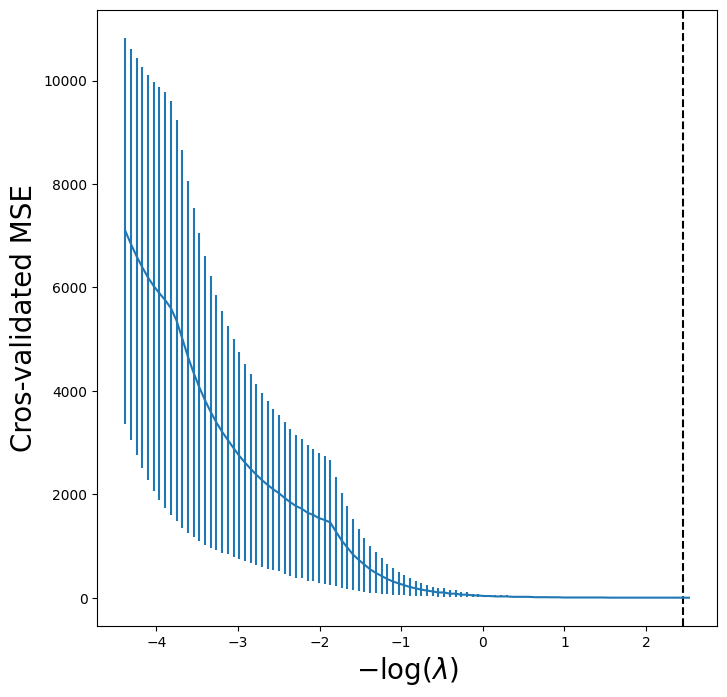

In [85]:
from matplotlib.pyplot import subplots

l_cv_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(l_cv.alphas_),
            l_cv.mse_path_.mean(1),
            yerr=l_cv.mse_path_.std(1)/ np.sqrt(5))
ax.axvline(-np.log(l_cv.alpha_), c='k', ls='--');
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Cros-validated MSE', fontsize=20)

(f) Now generate a response vector Y according to the model

$Y =\beta_0+\beta_7X^7+\epsilon$

In [86]:
y_2 = 28 + 6*x**7 + ruido*10

In [87]:
modelo_completo_2 = OLS(y_2, X).fit()
variancia_modelo_completo_2 = modelo_completo_2.scale

print("R2 modelo completo:", modelo_completo_2.rsquared)
print("Variância modelo completo:", variancia_modelo_completo_2)

summarize(modelo_completo_2)

R2 modelo completo: 0.9899442169964725
Variância modelo completo: 245.06145167339102


,coef,std err,t,P>|t|
x_1,-1.7944,11.599,-0.155,0.877
x_2,217.0056,23.256,9.331,0.000
x_3,-7.5945,47.012,-0.162,0.872
x_4,-423.1427,70.366,-6.013,0.000
x_5,11.0049,56.467,0.195,0.846
x_6,314.7750,68.940,4.566,0.000
x_7,3.5604,23.607,0.151,0.880
x_8,-97.1469,25.754,-3.772,0.000
x_9,-0.2845,2.915,-0.098,0.922
x_10,10.3001,3.071,3.354,0.001


In [88]:
neg_Cp_2 = partial(nCp, variancia_modelo_completo_2)

modelo_forward_Cp_2 = sklearn_selected(model_type=OLS,
                                       strategy=estrategia_forward,
                                       scoring=neg_Cp_2)
modelo_forward_Cp_2.fit(X, y_2)
print("R2 modelo foward selection Cp:", modelo_forward_Cp_2.results_.rsquared)
print("MSE modelo foward selection Cp:", modelo_forward_Cp_2.results_.mse_resid)
summarize(modelo_forward_Cp_2.results_)


R2 modelo foward selection Cp: 0.9955316911822343
MSE modelo foward selection Cp: 96.55992409048244


,coef,std err,t,P>|t|
intercept,27.8954,0.983,28.388,0.0
x_7,6.0248,0.041,147.764,0.0


In [89]:

l_cv_2 = LassoCV(n_alphas=100, cv=5)

pipe_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', l_cv_2)
])
pipe_2.fit(X, y_2)
l_cv_2 = pipe_2.named_steps['lasso']
print(f'Alfa: {l_cv_2.alpha_}\nR2: {pipe_2.score(X, y_2)}\nMSE: {mean_squared_error(y_2, pipe_2.predict(X))}')
pd.DataFrame(np.append(l_cv_2.intercept_,l_cv_2.coef_), index=np.append('intercepto', X.columns), columns=['coeficiente'])

Alfa: 0.1556934995277739
R2: 0.995713673563776
MSE: 90.77474828730749


c:\Users\olive\.conda\envs\ISLP\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


,coeficiente
intercepto,27.485107
x_1,-1.353401
x_2,-0.000000
x_3,-0.000000
x_4,-0.955966
x_5,24.503923
x_6,-0.000000
x_7,101.692164
x_8,-0.000000
x_9,20.360668


o Foward Selection Selecionou apenas o preditor correto e finalizou o modelo bem próximo ao modelo verdadeiro.

$Y = 28 + 6 x^7 + \epsilon$

$\hat{Y} = 27.8954 + 6.0248 x^7$

O lasso porém, considerou mais preditores

$\hat{Y}´ = 27.485107 + -1.353401x^1 -0.955966x^4 + 24.503923 x^5 + 101.692164 x^7 + 20.360668 x^9$

Isso indica que o modelo com o lasso apesar de fazer uma seleção de preditores, ainda há valores de coeficientes que não respresentam o modelo verdadeiro, o modelo está tentando explicar o ruído do sistema.

# 9 #
In this exercise, we will predict the number of applications received
using the other variables in the College data set.

(a) Split the data set into a training set and a test set.

In [90]:
from ISLP import load_data
from sklearn.model_selection import train_test_split

College = load_data('College')
College.Private = College.Private.map({'Yes':1, 'No':0})
X_treino, X_teste, y_treino, y_teste = train_test_split(College.drop(columns=['Apps']), College.Apps, random_state=42)
College.head(3)


,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54


(b) Fit a linear model using least squares on the training set, and
report the test error obtained.

In [91]:
design = ModelSpec(X_treino).fit(X_treino)
modelo_linear = OLS(y_treino, design.transform(X_treino) ).fit()
print(f"Modelo Linear\nMSE: {modelo_linear.mse_resid}\nR2: {modelo_linear.rsquared}")
summarize(modelo_linear)

Modelo Linear
MSE: 908698.3116199526
R2: 0.9434660715063493


,coef,std err,t,P>|t|
intercept,-259.5390,436.386,-0.595,0.552
Private[1],-626.4455,152.328,-4.112,0.000
Accept,1.7156,0.043,39.588,0.000
Enroll,-1.2578,0.198,-6.368,0.000
Top10perc,43.8312,5.805,7.551,0.000
Top25perc,-10.0355,4.716,-2.128,0.034
F.Undergrad,0.0626,0.035,1.775,0.076
P.Undergrad,-0.0126,0.042,-0.299,0.765
Outstate,-0.0763,0.020,-3.814,0.000
Room.Board,0.1739,0.052,3.369,0.001


In [92]:
from sklearn.metrics import mean_squared_error, r2_score

modelo_linear_predicao = modelo_linear.predict(design.transform(X_teste))
modelo_linear_mse = mean_squared_error(y_teste, modelo_linear_predicao)
modelo_linear_r2 = r2_score(y_teste, modelo_linear_predicao)

print(f"Modelo Linear Validação:\nMSE: {modelo_linear_mse}\nR2: {modelo_linear_r2}")

Modelo Linear Validação:
MSE: 1817982.645528679
R2: 0.8606501781209465


(c) Fit a ridge regression model on the training set, with λ chosen
by cross-validation. Report the test error obtained.

In [93]:
from sklearn.linear_model import RidgeCV

modelo_ridge = RidgeCV(alphas=np.random.default_rng(seed=42).uniform(low=1e-4, high=1e2, size=100), cv=10)
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', modelo_ridge)
])

pipe_ridge.fit(X_treino, y_treino)

print(f'Modelo Ridge:\nMSE: {mean_squared_error(y_treino,pipe_ridge.predict(X_treino))}\nR2: {pipe_ridge.score(X_treino, y_treino)}\nAlpha: {pipe_ridge.named_steps['ridge'].alpha_}')
pd.DataFrame(np.append(pipe_ridge.named_steps['ridge'].intercept_, pipe_ridge.named_steps['ridge'].coef_), index=np.append('intercepto', X_treino.columns), columns=['Coeficientes'])

Modelo Ridge:
MSE: 898194.8386140013
R2: 0.9423361175150629
Alpha: 5.830368338632432


,Coeficientes
intercepto,2924.431271
Private,-259.316362
Accept,3961.946452
Enroll,-685.387959
Top10perc,668.777328
Top25perc,-131.253404
F.Undergrad,206.681304
P.Undergrad,-24.632603
Outstate,-275.419200
Room.Board,210.984811


In [94]:
modelo_ridge_predicao = pipe_ridge.predict(X_teste)
modelo_ridge_mse = mean_squared_error(y_teste, modelo_ridge_predicao)
modelo_ridge_r2 = r2_score(y_teste, modelo_ridge_predicao)

print(f"Modelo Ridge:\nMSE: {modelo_ridge_mse}\nR2: {modelo_ridge_r2}")

Modelo Ridge:
MSE: 1701976.914150338
R2: 0.8695421100897581


(d) Fit a lasso model on the training set, with λ chosen by cross
validation. Report the test error obtained, along with the num
ber of non-zero coefficient estimates.

In [95]:

modelo_lasso = LassoCV(n_alphas=100, cv=10)
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', modelo_lasso)
])
pipe_lasso.fit(X_treino, y_treino)
print(f"Modelo Lasso\nMSE: {mean_squared_error(y_treino, pipe_lasso.predict(X_treino))}\nR2: {pipe_lasso.score(X_treino,y_treino)}\nAlpha: {pipe_lasso.named_steps['lasso'].alpha_}") 
pd.DataFrame(np.append(pipe_lasso.named_steps['lasso'].intercept_,pipe_lasso.named_steps['lasso'].coef_), index=np.append(['intercepto'], X_treino.columns), columns=['Coeficientes'])

Modelo Lasso
MSE: 882419.8210898768
R2: 0.943348869668162
Alpha: 3.774012851544714


c:\Users\olive\.conda\envs\ISLP\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


,Coeficientes
intercepto,2924.431271
Private,-268.764283
Accept,4257.744603
Enroll,-946.482127
Top10perc,716.319097
Top25perc,-156.712312
F.Undergrad,175.644890
P.Undergrad,-3.679600
Outstate,-285.455813
Room.Board,182.936298


In [96]:
modelo_lasso_predicao = pipe_lasso.predict(X_teste)
modelo_lasso_mse = mean_squared_error(y_teste, modelo_lasso_predicao)
modelo_lasso_r2 = r2_score(y_teste, modelo_lasso_predicao)

print(f"Modelo Lasso Validação:\nMSE: {modelo_lasso_mse}\nR2: {modelo_lasso_r2}")

Modelo Lasso Validação:
MSE: 1801154.19927191
R2: 0.8619400919681164


(e) Fit a PCR model on the training set, with M chosen by cross
validation. Report the test error obtained, along with the value
of M selected by cross-validation.

In [97]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

param_grid = {'pca__n_components': range(1, X_treino.shape[1])}
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(2)),
    ('linreg', LinearRegression())
])

grid_pca = GridSearchCV(pipe_pca, param_grid, cv=10, scoring='neg_mean_squared_error')
grid_pca.fit(X_treino, y_treino)

print(f'Modelo PCA:\nMSE: {mean_squared_error(y_treino,grid_pca.best_estimator_.predict(X_treino))}\nR2: {grid_pca.best_estimator_.score(X_treino, y_treino)}\nNº componentes PCA: {grid_pca.best_params_['pca__n_components']}')

pd.DataFrame(np.append(grid_pca.best_estimator_.named_steps['linreg'].intercept_,grid_pca.best_estimator_.named_steps['linreg'].coef_), index=np.append('intercepto', grid_pca.best_estimator_.named_steps['pca'].get_feature_names_out()), columns=['Coeficientes'])

Modelo PCA:
MSE: 978558.7730625717
R2: 0.9371767731580852
Nº componentes PCA: 16


,Coeficientes
intercepto,2924.431271
pca0,159.448700
pca1,1596.253977
pca2,105.156883
pca3,-1308.239560
pca4,423.975522
pca5,137.820234
pca6,-194.610505
pca7,18.306021
pca8,-722.090768


In [98]:
melhor_pca = grid_pca.best_estimator_.named_steps['pca']

#Pegar a matriz de componentes (pesos) e os nomes originais e finais
pesos_componentes = melhor_pca.components_
colunas_originais = X_treino.columns
colunas_finais_pca = melhor_pca.get_feature_names_out()

#Criar um DataFrame explicativo da transformação
df_transformacao = pd.DataFrame(
    pesos_componentes, 
    columns=colunas_originais, 
    index=colunas_finais_pca
).T

print("Matriz de Transformação (Pesos de cada variável original nas colunas do PCA):")
df_transformacao


Matriz de Transformação (Pesos de cada variável original nas colunas do PCA):


,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12,pca13,pca14,pca15
Private,0.220411,-0.309999,0.161319,-0.159962,0.120193,-0.013691,0.151791,-0.085631,0.112389,-0.152696,0.656233,0.318267,-0.417210,-0.072688,-0.051546,-0.092380
Accept,-0.000416,0.419476,0.007271,-0.339097,0.170445,0.034976,-0.015739,0.077726,-0.196206,-0.124476,0.166084,0.003997,-0.071296,0.000957,0.521666,0.532211
Enroll,-0.046984,0.440763,-0.007523,-0.294526,0.074740,-0.032237,-0.011723,0.123897,-0.109102,-0.097492,0.107897,-0.009530,-0.039961,0.019816,-0.227075,-0.208665
Top10perc,0.340748,0.135989,0.005397,-0.092496,-0.406610,-0.090845,-0.180117,-0.286460,0.160880,-0.062701,-0.021013,-0.041054,-0.081841,0.138226,-0.487418,0.522846
Top25perc,0.311252,0.170759,-0.071252,-0.114057,-0.446017,-0.016714,-0.128150,-0.313975,0.224419,-0.019221,0.117139,-0.208384,0.100609,-0.173074,0.468187,-0.417530
F.Undergrad,-0.075106,0.444382,-0.003624,-0.232467,0.064433,-0.048723,-0.006147,0.093650,-0.031348,-0.055733,0.073229,-0.026596,-0.011444,-0.019014,-0.401978,-0.391939
P.Undergrad,-0.148422,0.302390,0.129390,0.123569,0.252454,-0.176802,0.108941,-0.047612,0.784955,0.282926,-0.022261,0.185094,0.011348,0.003040,0.069385,0.087841
Outstate,0.375912,-0.033925,0.105055,-0.031598,0.246290,-0.000379,0.121948,-0.033222,0.007178,-0.248878,0.097263,0.216016,0.800777,0.077099,-0.058570,0.011600
Room.Board,0.285865,0.037145,0.206166,0.057164,0.504715,0.261780,0.149571,-0.355293,0.031396,-0.153484,-0.236099,-0.507797,-0.236752,0.022498,-0.040977,-0.051581
Books,0.013467,0.078882,0.667691,0.062508,-0.246806,0.583607,-0.170342,0.310148,0.072850,0.063643,0.023261,0.045708,0.025807,0.063877,0.011893,-0.016481


In [99]:
modelo_pca_mse = mean_squared_error(y_teste,grid_pca.best_estimator_.predict(X_teste))
modelo_pca_r2 = grid_pca.best_estimator_.score(X_teste, y_teste)
print(f'Modelo PCA:\nMSE: {modelo_pca_mse}\nR2: {modelo_pca_r2}')

Modelo PCA:
MSE: 1741935.2954931874
R2: 0.8664792682433872


(f) Fit a PLS model on the training set, with M chosen by cross
validation. Report the test error obtained, along with the value
of M selected by cross-validation.

In [100]:
from sklearn.cross_decomposition import PLSRegression

param_grid = {'pls__n_components': range(1, X_treino.shape[1])}

pipe_pls = Pipeline([
    ('scaler', StandardScaler()),
    ('pls', PLSRegression(n_components=2))
])

grid_pls = GridSearchCV(pipe_pls, param_grid, cv=10, scoring='neg_mean_squared_error', return_train_score=True)
grid_pls.fit(X_treino, y_treino)
print(f'Modelo PLS:\nMSE: {mean_squared_error(y_treino, grid_pls.best_estimator_.predict(X_treino))}\nR2: {grid_pls.best_estimator_.score(X_treino, y_treino)}\nNº componentes PCA: {grid_pls.best_params_['pls__n_components']}')
pd.DataFrame(np.append(grid_pls.best_estimator_.named_steps['pls'].intercept_,grid_pls.best_estimator_.named_steps['pls'].coef_),index=np.append('intercepto',X_treino.columns), columns=['coeficientes'])

Modelo PLS:
MSE: 880904.8053224271
R2: 0.9434461332989705
Nº componentes PCA: 13


,coeficientes
intercepto,2924.431271
Private,-276.754322
Accept,4305.244909
Enroll,-1079.995832
Top10perc,781.986837
Top25perc,-219.446806
F.Undergrad,267.550877
P.Undergrad,-13.133753
Outstate,-306.572718
Room.Board,192.843068


In [101]:
pd.DataFrame(
    grid_pls.best_estimator_.named_steps['pls'].x_loadings_, 
    index=X_treino.columns, 
    columns=grid_pls.best_estimator_.get_feature_names_out()
)

,plsregression0,plsregression1,plsregression2,plsregression3,plsregression4,plsregression5,plsregression6,plsregression7,plsregression8,plsregression9,plsregression10,plsregression11,plsregression12
Private,-0.269195,0.014055,-0.315628,-0.215970,0.265610,0.126419,-0.230734,0.418971,0.232164,-0.172581,-0.075347,-0.041588,-0.134495
Accept,0.439181,0.352923,-0.013341,0.344197,0.154289,-0.080470,0.016563,0.035516,0.099564,0.039878,0.030018,-0.038544,-0.014310
Enroll,0.448618,0.283009,0.070048,-0.056727,-0.188999,0.053752,-0.168906,0.050730,-0.035142,0.075092,0.050627,-0.119194,-0.180705
Top10perc,0.185045,-0.334936,-0.328655,-0.244884,0.223440,0.037650,-0.212017,-0.445037,-0.337236,-0.530315,-0.013646,-0.160095,-0.167882
Top25perc,0.215221,-0.319594,-0.289260,-0.280918,0.175611,-0.040451,-0.361763,-0.280705,-0.513700,-0.417153,0.260502,-0.110984,0.251783
F.Undergrad,0.444529,0.232884,0.117465,-0.158671,-0.195309,0.047929,-0.108735,-0.043863,0.105076,-0.157402,-0.226283,0.015352,0.060032
P.Undergrad,0.273368,-0.068952,0.259941,-0.731477,0.532220,-0.204288,0.218482,0.395168,0.245725,0.224163,-0.225040,-0.221440,0.156936
Outstate,0.026269,-0.223887,-0.418577,-0.284153,-0.079181,0.093942,0.219757,-0.074219,0.597445,0.189459,0.325334,-0.205722,0.266412
Room.Board,0.085039,-0.133401,-0.318817,-0.094272,0.040076,0.093116,0.353295,0.808008,0.541153,0.086581,0.051481,0.161518,-0.092554
Books,0.080617,-0.031231,0.006758,-0.192153,0.588482,0.624806,0.680305,0.228303,-0.342817,-0.633993,0.584811,0.344104,-0.139185


In [102]:
modelo_pls_mse = mean_squared_error(y_teste, grid_pls.best_estimator_.predict(X_teste))
modelo_pls_r2 = grid_pls.best_estimator_.score(X_teste, y_teste)
print(f'Modelos PLS:\nMSE: {modelo_pls_mse}\nR2: {modelo_pls_r2}')

Modelos PLS:
MSE: 1800085.5238994292
R2: 0.862022006789013


(g) Comment on the results obtained. How accurately can we pre
dict the number of college applications received? Is there much
difference among the test errors resulting from these five approaches?

Informações gerais de Apps:
count      777.000000
mean      3001.638353
std       3870.201484
min         81.000000
25%        776.000000
50%       1558.000000
75%       3624.000000
max      48094.000000
Name: Apps, dtype: float64


Text(0.5, 0, 'Modelos')

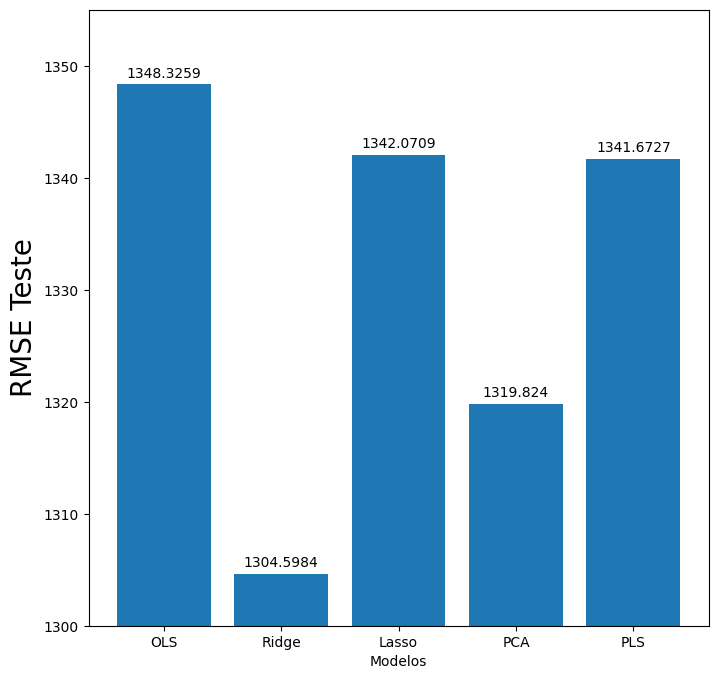

In [103]:
nomes_modelos = ['OLS', 'Ridge', 'Lasso', 'PCA', 'PLS']
mse_modelos = [modelo_linear_mse, modelo_ridge_mse, modelo_lasso_mse, modelo_pca_mse, modelo_pls_mse]

print(f'Informações gerais de Apps:\n{College.Apps.describe()}')

fig, ax = subplots(figsize=(8,8))
barras = ax.bar(nomes_modelos, np.sqrt(mse_modelos))
ax.bar_label(barras, labels=[f"{v}" for v in np.sqrt(mse_modelos).round(4)], padding=3)
ax.set_ylim([1_300, 1_355])
ax.set_ylabel('RMSE Teste', fontsize=20)
ax.set_xlabel('Modelos')

O modelo Linear sem regularização foi o pior conforme esperado. 

O lasso não teve uma grande melhora pois os preditores contribuem para explicar Y, o Lasso zerou apenas um preditor.

O PLS não foi muito diferente do lasso, o número de componentes foi de 12, quer dizer que 5 dimensões não contribuem para explicação de Y, porém o resultado não foi muito melhor do que o Linear.

o PCA foi com 16 componentes, caso não fosse limitado para ser até p-1 utilizaria todas as dimensões, isso revela que não há multicolinearidade nos dados.

Ridge foi o melhor, como vimos anteriormente, todos os preditores contribuem para explicar o Y de alguma forma, adicionando a penalidade $\ell_2$ os coeficientes deixaram de captar ruídos melhorando o modelo final.

# 10 #
We have seen that as the number of features used in a model increases,
the training error will necessarily decrease, but the test error may not.
We will now explore this in a simulated data set.

(a) Generate a data set with p = 20 features, n =1,000 observations, and an associated quantitative response vector generated
according to the model

$Y =X\beta +\epsilon$,

where $\beta$ has some elements that are exactly equal to zero.

In [104]:

rdn = np.random.default_rng(seed=42)
p = 20
n = 1000

betas = rdn.normal(size=p)
for i in range(0, p, 3):
    betas[i] = 0
epsilon = rdn.normal() * 10
X = pd.DataFrame(rdn.normal(size=(n,p)), columns=[f'x_{i+1}' for i in range(0, p)])

y = np.dot(X,betas) + epsilon

X.head(3)

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,x_11,x_12,x_13,x_14,x_15,x_16,x_17,x_18,x_19,x_20
0,-0.680930,1.222541,-0.154529,-0.428328,-0.352134,0.532309,0.365444,0.412733,0.430821,2.141648,-0.406415,-0.512243,-0.813773,0.615979,1.128972,-0.113947,-0.840156,-0.824481,0.650593,0.743254
1,0.543154,-0.665510,0.232161,0.116686,0.218689,0.871429,0.223596,0.678914,0.067579,0.289119,0.631288,-1.457156,-0.319671,-0.470373,-0.638878,-0.275142,1.494941,-0.865831,0.968278,-1.682870
2,-0.334885,0.162753,0.586222,0.711227,0.793347,-0.348725,-0.462352,0.857976,-0.191304,-1.275686,-1.133287,-0.919452,0.497161,0.142426,0.690485,-0.427253,0.158540,0.625590,-0.309347,0.456775


In [105]:
y[:5], betas

(array([-2.46990475, -2.70114629, -4.73242067, -5.98252766, -1.41950755]),
 array([ 0.        , -1.03998411,  0.7504512 ,  0.        , -1.95103519,
        -1.30217951,  0.        , -0.31624259, -0.01680116,  0.        ,
         0.87939797,  0.77779194,  0.        ,  1.12724121,  0.46750934,
         0.        ,  0.36875078, -0.9588826 ,  0.        , -0.04992591]))

(b) Split your data set into a training set containing 100 observations
and a test set containing 900 observations.

In [106]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.9)

(c) Perform best subset selection on the training set, and plot the
training set MSE associated with the best model of each size.

In [107]:
from itertools import combinations

modelo_completo = OLS(y_treino, X_treino).fit()
modelo_completo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.869
Model:                            OLS   Adj. R-squared (uncentered):              0.836
Method:                 Least Squares   F-statistic:                              26.56
Date:                Tue, 25 Aug 2026   Prob (F-statistic):                    2.85e-27
Time:                        17:23:52   Log-Likelihood:                         -186.17
No. Observations:                 100   AIC:                                      412.3
Df Residuals:                      80   BIC:                                      464.4
Df Model:                          20                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x_1           -0.2570      0.183     -1.406      0.164      -0.621       0.107
x_2           -1.3208      0.185     -7.126      0.000      -1.690      -0.952
x_3            0.3522      0.182      1.935      0.057      -0.010       0.714
x_4            0.0563      0.212      0.266      0.791      -0.365       0.478
x_5           -2.0823      0.193    -10.774      0.000      -2.467      -1.698
x_6           -1.2167      0.167     -7.282      0.000      -1.549      -0.884
x_7            0.1020      0.184      0.553      0.581      -0.265       0.469
x_8           -0.4498      0.201     -2.238      0.028      -0.850      -0.050
x_9           -0.2228      0.199     -1.120      0.266      -0.619       0.173
x_10          -0.0378      0.204     -0.185      0.854      -0.444       0.369
x_11           1.4323      0.207      6.912      0.000       1.020       1.845
x_12           0.6428      0.207      3.111      0.003       0.232       1.054
x_13           0.1999      0.157      1.274      0.206      -0.112       0.512
x_14           1.0322      0.206      5.017      0.000       0.623       1.442
x_15           0.6189      0.177      3.506      0.001       0.268       0.970
x_16           0.1429      0.181      0.791      0.432      -0.217       0.503
x_17           0.4661      0.197      2.366      0.020       0.074       0.858
x_18          -1.3159      0.169     -7.800      0.000      -1.652      -0.980
x_19          -0.1061      0.171     -0.622      0.535      -0.445       0.233
x_20          -0.0827      0.197     -0.420      0.676      -0.475       0.309
==============================================================================
Omnibus:                        0.456   Durbin-Watson:                   0.536
Prob(Omnibus):                  0.796   Jarque-Bera (JB):                0.614
Skew:                          -0.098   Prob(JB):                        0.736
Kurtosis:                       2.670   Cond. No.                         2.35
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [108]:
predicao_modelo_completo = modelo_completo.predict(X_teste)
mse_modelo_completo = mean_squared_error(y_teste, predicao_modelo_completo)
r2_modelo_completo = r2_score(y_teste, predicao_modelo_completo)

print(f"Modelo completo:\nMSE: {mse_modelo_completo}\nRSS: {r2_modelo_completo}")

Modelo completo:
MSE: 4.328610758534532
RSS: 0.6372430929535826


In [109]:
modelo_nulo = LinearRegression(fit_intercept=False).fit(np.zeros((len(y_treino), 1)),y=y_treino)
predicao_modelo_nulo = modelo_nulo.predict(np.zeros((len(y_teste), 1)))
mse_modelo_nulo = mean_squared_error(y_teste, predicao_modelo_nulo)
r2_modelo_nulo = r2_score(y_teste, predicao_modelo_nulo)
print(f"Modelo Nulo:\nMSE: {mse_modelo_nulo}\nRSS: {r2_modelo_nulo}")

Modelo Nulo:
MSE: 15.29050388015427
RSS: -0.2814124910191451


In [110]:

def encontrar_melhor_modelo_subset(X_treino, y_treino, X_teste, y_teste, m=1, intercepto=False):
    mse_melhor_subset = np.inf
    info_melhor_modelo = None
    for combinacao  in combinations(X.columns,m):
        preditores = list(combinacao)
        modelo_subset = LinearRegression(fit_intercept=intercepto).fit(X_treino[preditores], y_treino)
        predicao_modelo_subset = modelo_subset.predict(X_teste[preditores])
        mse_modelo_subset = mean_squared_error(y_teste, predicao_modelo_subset)
        r2_modelo_subset = r2_score(y_teste, predicao_modelo_subset)

        if mse_modelo_subset < mse_melhor_subset:
            mse_melhor_subset = mse_modelo_subset
            info_melhor_modelo = {
                "MSE": np.round(mse_modelo_subset, 4),
                "R2": np.round(r2_modelo_subset, 4),
                "Preditores":", ".join(preditores),
                "M":len(preditores),
                "Modelo": modelo_subset
            }

    return info_melhor_modelo

encontrar_melhor_modelo_subset(X_treino, y_treino, X_teste, y_teste)

{'MSE': np.float64(11.0768),
 'R2': np.float64(0.0717),
 'Preditores': 'x_5',
 'M': 1,
 'Modelo': LinearRegression(fit_intercept=False)}

In [111]:
lista_subset = [{
    "MSE": np.round(mse_modelo_nulo, 4),
    "R2": np.round(r2_modelo_nulo, 4),
    "Preditores":" ",
    "M":0,
    "Modelo": modelo_nulo
}]

for i in range(1, 20):
    lista_subset.append(encontrar_melhor_modelo_subset(X_treino, y_treino, X_teste, y_teste, i))

lista_subset.append({
    "MSE": np.round(mse_modelo_completo, 4),
    "R2": np.round(r2_modelo_completo, 4),
    "Preditores": ",".join(X_treino.columns),
    "M":len(X_treino.columns),
    "Modelo": modelo_completo
})

melhores_subsets_df = pd.DataFrame(lista_subset)

(d) Plot the test set MSE associated with the best model of each
size.

In [112]:
melhores_subsets_df

,MSE,R2,Preditores,M,Modelo
0,15.2905,-0.2814,,0,LinearRegression(fit_intercept=False)
1,11.0768,0.0717,x_5,1,LinearRegression(fit_intercept=False)
2,9.4359,0.2092,"x_5, x_6",2,LinearRegression(fit_intercept=False)
3,8.3866,0.2972,"x_5, x_6, x_12",3,LinearRegression(fit_intercept=False)
4,7.2707,0.3907,"x_2, x_5, x_6, x_14",4,LinearRegression(fit_intercept=False)
5,6.3935,0.4642,"x_2, x_5, x_6, x_14, x_18",5,LinearRegression(fit_intercept=False)
6,5.5684,0.5333,"x_2, x_5, x_6, x_12, x_14, x_18",6,LinearRegression(fit_intercept=False)
7,5.0658,0.5755,"x_2, x_5, x_6, x_11, x_12, x_14, x_18",7,LinearRegression(fit_intercept=False)
8,4.7387,0.6029,"x_2, x_5, x_6, x_11, x_12, x_14, x_15, x_18",8,LinearRegression(fit_intercept=False)
9,4.4518,0.6269,"x_2, x_3, x_5, x_6, x_11, x_12, x_14, x_15, x_18",9,LinearRegression(fit_intercept=False)


Text(0, 0.5, 'MSE')

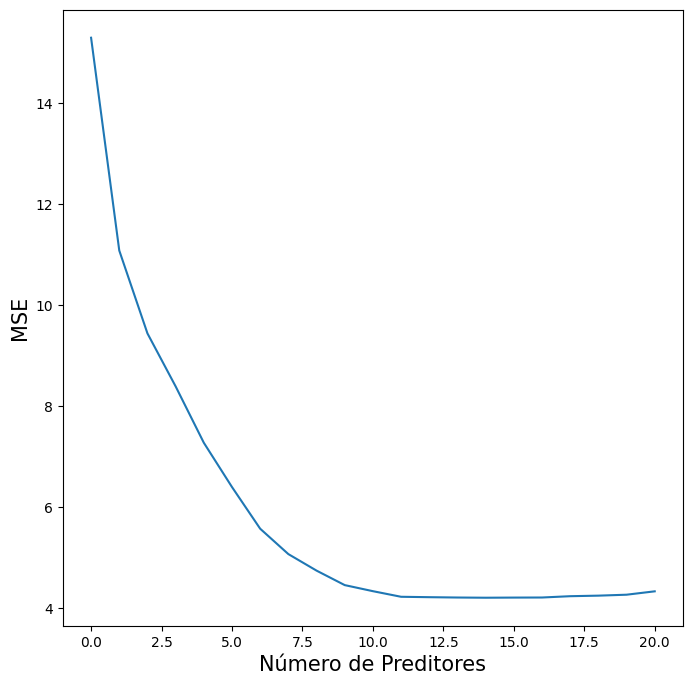

In [113]:
fig, ax = subplots(figsize=(8,8))
ax.plot(melhores_subsets_df.M, melhores_subsets_df.MSE)
ax.set_xlabel("Número de Preditores", fontsize=15)
#ax.set_xticks(melhores_subsets_df.M)
ax.set_ylabel("MSE", fontsize=15)

(f) How does the model at which the test set MSE is minimized
compare to the true model used to generate the data? Comment
on the coefficient values.

In [114]:
melhor_subset = melhores_subsets_df.loc[melhores_subsets_df.M<20].sort_values(by='MSE').iloc[0]
df_betas_coef = pd.DataFrame(modelo_completo.params,columns=['modelo_completo']).join(pd.DataFrame(melhor_subset.Modelo.coef_, index=melhor_subset.Preditores.replace(' ','').split(','),columns=['melhor_subset'])).join(pd.DataFrame(betas, index=X_teste.columns, columns=['beta_real']))
df_betas_coef

,modelo_completo,melhor_subset,beta_real
x_1,-0.257044,NaN,0.000000
x_2,-1.320806,-1.280877,-1.039984
x_3,0.352168,0.298095,0.750451
x_4,0.056309,0.034361,0.000000
x_5,-2.082337,-2.048643,-1.951035
x_6,-1.216747,-1.167532,-1.302180
x_7,0.101981,0.028426,0.000000
x_8,-0.449755,-0.486092,-0.316243
x_9,-0.222777,NaN,-0.016801
x_10,-0.037825,NaN,0.000000


(g) Create a plot displaying $\sqrt{\sum_{j=1}^{p} (\beta_j - \hat\beta_j^r)^2}$ for a range of values of r, where $\hat{\beta_j^r}^2$ is the jth coefficient estimate for the best model
containing r coefficients. Comment on what you observe. How does this compare to the test MSE plot from (d)?

In [115]:
coeficientes_erro = []

df_coeficientes_p = pd.DataFrame(betas, index=X_teste.columns, columns=['beta_real'])
for i in range(0,melhores_subsets_df.shape[0]):
    if hasattr(melhores_subsets_df.iloc[i].Modelo, 'coef_'):
        coeficientes = melhores_subsets_df.iloc[i].Modelo.coef_ 
    elif hasattr(melhores_subsets_df.iloc[i].Modelo, 'params'):
        coeficientes = melhores_subsets_df.iloc[i].Modelo.params      
    else:
        coeficientes = None
    nome_coluna = f'M_{melhores_subsets_df.iloc[i].M}'
    df_coef_modelo = pd.DataFrame(coeficientes, index=melhores_subsets_df.iloc[i].Preditores.replace(' ','').split(','), columns=[nome_coluna])
    df_coeficientes_p = df_coeficientes_p.join(df_coef_modelo)
    erro = np.sqrt(np.sum((df_coeficientes_p['beta_real'] - df_coeficientes_p[nome_coluna].fillna(0))**2))
    coeficientes_erro.append(erro)

df_coeficientes_p

,beta_real,M_0,M_1,M_2,M_3,M_4,M_5,M_6,M_7,M_8,...,M_11,M_12,M_13,M_14,M_15,M_16,M_17,M_18,M_19,M_20
x_1,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.213690,-0.234915,-0.257044
x_2,-1.039984,NaN,NaN,NaN,NaN,-1.503558,-1.555890,-1.549690,-1.407632,-1.281834,...,-1.284855,-1.282297,-1.281351,-1.280877,-1.292883,-1.292534,-1.307591,-1.311837,-1.314351,-1.320806
x_3,0.750451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.294480,0.295817,0.296560,0.298095,0.305131,0.303777,0.291151,0.289238,0.343043,0.352168
x_4,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.034361,0.043110,0.042790,0.086166,0.035534,0.072949,0.056309
x_5,-1.951035,NaN,-2.275864,-2.216672,-2.121380,-2.339412,-2.136485,-2.057455,-2.049522,-2.050315,...,-2.052606,-2.051361,-2.049933,-2.048643,-2.065202,-2.063995,-2.082738,-2.092606,-2.104144,-2.082337
x_6,-1.302180,NaN,NaN,-1.302544,-1.133412,-1.204806,-1.309757,-1.161405,-1.313084,-1.234113,...,-1.165515,-1.166479,-1.166344,-1.167532,-1.172279,-1.173220,-1.136394,-1.146564,-1.186499,-1.216747
x_7,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.021967,0.028426,0.022108,0.021480,0.056148,0.049946,0.073598,0.101981
x_8,-0.316243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.484159,-0.484424,-0.485695,-0.486092,-0.474495,-0.474586,-0.457251,-0.446197,-0.451696,-0.449755
x_9,-0.016801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.238578,-0.222777
x_10,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.010446,-0.011330,-0.048641,-0.012695,-0.037825


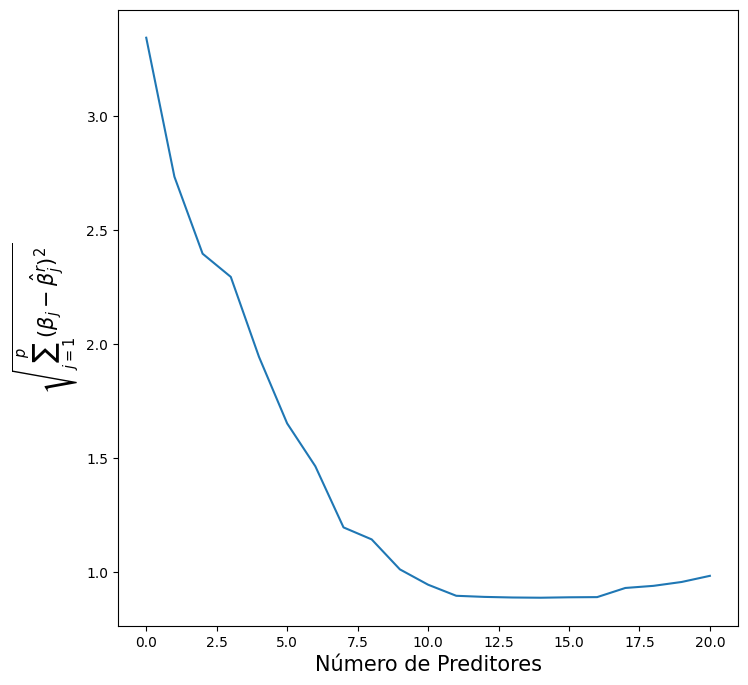

In [116]:
fig, ax = subplots(figsize=(8,8))
ax.plot(melhores_subsets_df.M, coeficientes_erro)
ax.set_xlabel("Número de Preditores", fontsize=15)
ax.set_ylabel('$\\sqrt{\\sum_{j=1}^{p} (\\beta_j - \\hat\\beta_j^r)^2}$', fontsize=15);